# Laboratory 3 — Transforming Textual and Image Data into a Machine-Understandable Format


  
---

## Learning Objectives

On completion of this laboratory you will be able to:

1. Explain why raw text and raw images cannot be fed directly to a traditional machine learning algorithm.
2. Apply the **Bag-of-Words** model with `CountVectorizer` to convert a corpus into a numerical document–term matrix.
3. Convert an image into a numerical array of pixel values with **Pillow** and **NumPy**.
4. Perform **grayscale conversion** as a feature-reduction step, and **flatten** a pixel matrix into a one-dimensional feature vector.
5. State precisely **what information each transformation discards**.

## Background

Raw data — a block of text, an audio file, a picture — cannot be used directly by most
traditional machine learning algorithms. Those algorithms require a **numerical, vector-based
input**. *Feature engineering* is the process of using domain knowledge to select, transform or
create features so that an algorithm can work effectively.

Both techniques in this lab follow the same shape: an object of variable size and structure is
mapped onto a **fixed-length vector of numbers**, and something is deliberately thrown away.

```
Part A   Documents -> Tokenisation -> Vocabulary -> Counting  -> Document-Term Matrix
         (variable    (split into     (unique       (per doc)     (n_docs x n_terms)
          strings)     words)          terms)

Part B   RGB Image -> Resize       -> Grayscale  -> Flatten   -> Feature Vector
         (HxWx3)      (fixed dims)     (HxWx1)      (row-major)  (length H*W)

                 both paths end in a fixed-length numeric vector
```

> **Instructor note.** No data files are required. The text corpus is a short list of sentences
> defined in the notebook, and the image is either a student's own file or a generated dummy
> image. The lab therefore runs on any machine, offline.

### Setup and prerequisites

| Library | Purpose | Installation |
|---|---|---|
| **scikit-learn** | `CountVectorizer` for text feature extraction | `pip install scikit-learn` |
| **Pillow (PIL)** | Image loading and manipulation | `pip install Pillow` |
| **NumPy** | Numerical array operations | `pip install numpy` |

In [2]:
%pip install scikit-learn Pillow numpy pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
# Part A — Feature engineering for text data

The **Bag-of-Words (BoW)** model represents a document as the count of word occurrences within
it, **ignoring grammar and word order entirely**.

## Task 3.1 — Vectorising text with `CountVectorizer`

**Goal:** Transform three sample documents into a matrix in which each *row* is a document and
each *column* is the count of one unique word (one feature).

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# 1. Define Sample Text Data (our "corpus")
documents = [
    "The sun is shining today.",
    "The weather is good, the sun is great.",
    "A sunny day is a wonderful day."
]

print("--- Raw Text Documents ---")
for i, doc in enumerate(documents):
    print(f"Doc {i+1}: {doc}")

--- Raw Text Documents ---
Doc 1: The sun is shining today.
Doc 2: The weather is good, the sun is great.
Doc 3: A sunny day is a wonderful day.


In [3]:
# 2. Apply Feature Engineering: CountVectorizer (Bag-of-Words)
#    CountVectorizer performs tokenization AND vocabulary building in one step.
vectorizer = CountVectorizer()

# fit_transform learns the vocabulary and converts the documents into feature vectors
X_text = vectorizer.fit_transform(documents)

# 3. Analyze the Results
feature_names = vectorizer.get_feature_names_out()
text_matrix = X_text.toarray()

print("--- Bag-of-Words (BoW) Transformation ---")
print(f"Vocabulary (Features): {feature_names}")
print(f"Shape of Feature Matrix: {text_matrix.shape}   (documents x unique terms)")
print(text_matrix)

--- Bag-of-Words (BoW) Transformation ---
Vocabulary (Features): ['day' 'good' 'great' 'is' 'shining' 'sun' 'sunny' 'the' 'today' 'weather'
 'wonderful']
Shape of Feature Matrix: (3, 11)   (documents x unique terms)
[[0 0 0 1 1 1 0 1 1 0 0]
 [0 1 1 2 0 1 0 2 0 1 0]
 [2 0 0 1 0 0 1 0 0 0 1]]


In [3]:
# A DataFrame view, purely so the matrix is readable
df_text = pd.DataFrame(text_matrix, columns=feature_names,
                       index=[f"Doc {i+1}" for i in range(len(documents))])

print("BoW Numerical Feature Matrix (Machine Understandable Format):\n")
display(df_text)

BoW Numerical Feature Matrix (Machine Understandable Format):



,day,good,great,is,shining,sun,sunny,the,today,weather,wonderful
Doc 1,0,0,0,1,1,1,0,1,1,0,0
Doc 2,0,1,1,2,0,1,0,2,0,1,0
Doc 3,2,0,0,1,0,0,1,0,0,0,1


### Expected output

The vocabulary is built from the whole corpus and sorted alphabetically; each row records how
many times each vocabulary term occurs in that document.

|       | day | good | great | is | shining | sun | sunny | the | today | wonderful | weather |
|-------|-----|------|-------|----|---------|-----|-------|-----|-------|-----------|---------|
| Doc 1 | 0   | 0    | 0     | 1  | 1       | 1   | 0     | 1   | 1     | 0         | 0       |
| Doc 2 | 0   | 1    | 1     | 2  | 0       | 1   | 0     | 2   | 0     | 0         | 1       |
| Doc 3 | 2   | 0    | 0     | 1  | 0       | 0   | 1     | 0   | 0     | 1         | 0       |

> ### Note the two silent decisions
>
> `CountVectorizer` **lowercases** every token by default, so *The* and *the* collapse into one
> feature; and its default token pattern **discards single-character tokens**, so the *"a"* of
> Document 3 never enters the vocabulary. Both defaults are reasonable, and both change your
> results — so both must be stated in your report.

In [4]:
# Prove the two silent decisions to yourself rather than taking them on trust.

print("Is 'a' in the vocabulary? ", 'a' in feature_names)
print("Is 'the' in the vocabulary?", 'the' in feature_names)
print()
print("Default token pattern :", vectorizer.token_pattern)
print("Lowercase enabled     :", vectorizer.lowercase)
print()
print("The token pattern requires 2+ word characters, which is why 'a' is dropped.")

Is 'a' in the vocabulary?  False
Is 'the' in the vocabulary? True

Default token pattern : (?u)\b\w\w+\b
Lowercase enabled     : True

The token pattern requires 2+ word characters, which is why 'a' is dropped.


In [7]:
# Sparsity: how much of this matrix is zero? This is the defining property of BoW.
total_cells = text_matrix.size   #total number of cells in the matrix (rows × columns). With 3 documents and 11 vocabulary terms, that's 3 × 11 = 33 cells.
zero_cells = (text_matrix == 0).sum()

print(f"Matrix cells : {total_cells}")
print(f"Zero cells   : {zero_cells}")
print(f"Sparsity     : {zero_cells / total_cells:.1%}")
print()
print("With a real corpus of 20,000 documents this figure exceeds 99%,")
print("which is why scikit-learn returns a SPARSE matrix, not a dense array.")
print("Type returned by fit_transform:", type(X_text))

Matrix cells : 33
Zero cells   : 18
Sparsity     : 54.5%

With a real corpus of 20,000 documents this figure exceeds 99%,
which is why scikit-learn returns a SPARSE matrix, not a dense array.
Type returned by fit_transform: <class 'scipy.sparse._csr.csr_matrix'>


## Discussion questions (Part A)

Answer these in the Markdown cell below.

1. What does each **column** in the resulting matrix represent?
2. In this specific numerical matrix, what is the *machine-understandable format*?
3. How is this format an **oversimplification** of the original text data? (Consider what information has been lost.)

**Your answers (Part A):**

1. Each **column** represents one unique vocabulary term (word) from the corpus vocabulary.
   The integer value in that column for a given document row records how many times that
   term appears in the document. A zero means the word does not appear in that document.

2. The machine-understandable format is a **fixed-length integer vector of word counts**
   known as the Document-Term Matrix (DTM). Every document maps to the same vector space,
   so any numerical algorithm can operate on it without knowing anything about language.

3. BoW is an oversimplification in at least three ways:
   - **Word order is discarded**: 'dog bites man' and 'man bites dog' produce identical
     count vectors even though their meaning is opposite.
   - **Semantics are ignored**: synonyms such as *good* and *great* are separate, unrelated
     features with no indicated similarity.
   - **Context and negation are lost**: the phrase 'not good' adds one count to 'not' and
     one to 'good'; the negative relationship between them is invisible to the model.

---

---
# Part B — Feature engineering for image data

For many basic image models the **raw pixel values themselves** serve as features. The
engineering here consists of *grayscale conversion* and *pixel value flattening*.

## Task 3.2 — Converting and flattening image pixels

**Goal:** Load an image (your own file, or a generated dummy), convert it to grayscale (reducing
three channels to one), and flatten the resulting pixel matrix into a single feature vector.

In [5]:
import numpy as np
from PIL import Image
import os

# --- Configuration for image loading ------------------------------------
# Set to None to use a dummy image, or to a path string for your own image.
#   e.g. 'my_image.png'  or  'C:/Users/You/Pictures/photo.jpg'
image_file_path = "images.jpg"   # place images.jpg next to this notebook

# 1. Load Image or Create a Dummy Image
original_image = None
if image_file_path and os.path.exists(image_file_path):
    try:
        original_image = Image.open(image_file_path)
        print(f"--- Loaded Image from File: {image_file_path} ---")
    except Exception as e:
        print(f"Error loading image from {image_file_path}: {e}")
        dummy = np.random.randint(0, 256, size=(100, 100, 3), dtype=np.uint8)
        original_image = Image.fromarray(dummy, 'RGB')
        print("--- Created Dummy Image (100x100 RGB) ---")
else:
    print("No valid image file path provided or file not found.")
    dummy = np.random.randint(0, 256, size=(100, 100, 3), dtype=np.uint8)
    original_image = Image.fromarray(dummy, 'RGB')
    print("--- Created Dummy Image (100x100 RGB) ---")

# Ensure a consistent 3-channel representation
original_image = original_image.convert('RGB')
original_image_array = np.array(original_image)

h, w, c = original_image_array.shape
print(f"Original Image Size (H, W, Channels): {original_image_array.shape}")
print(f"Total Features (Pixels) in RGB: {h * w * c}")

--- Loaded Image from File: C:/Users/AL KARAM COMPUTERS/Desktop/NLP Project/Lab 03 - Text and Image Features/lena.jpg ---
Original Image Size (H, W, Channels): (148, 148, 3)
Total Features (Pixels) in RGB: 65712


In [6]:
# 2. Feature Engineering step 1: Grayscale Conversion ('L' mode = luminance)
grayscale_image = original_image.convert('L')
grayscale_array = np.array(grayscale_image)

print("--- Grayscale Conversion (Feature Reduction) ---")
print(f"Grayscale Image Size (H, W): {grayscale_array.shape}")
print(f"Total Features (Pixels) after Grayscale: {grayscale_array.size}")
print()
print(f"Reduction factor: {(h * w * c) / grayscale_array.size:.0f}x fewer features")

--- Grayscale Conversion (Feature Reduction) ---
Grayscale Image Size (H, W): (148, 148)
Total Features (Pixels) after Grayscale: 21904

Reduction factor: 3x fewer features


In [7]:
# 3. Feature Engineering step 2: Pixel Flattening (2D matrix -> 1D vector)
flattened_features = grayscale_array.flatten()

print("--- Pixel Flattening (Vectorization) ---")
print(f"Flattened Feature Vector Shape: {flattened_features.shape}")
print()
print("First 10 Features (Pixel Values) in Machine Understandable Format:")
print(flattened_features[:10])
print()
print(f"Data Type of Final Features: {flattened_features.dtype}")

--- Pixel Flattening (Vectorization) ---
Flattened Feature Vector Shape: (21904,)

First 10 Features (Pixel Values) in Machine Understandable Format:
[160 160 161 160 159 157 156 155 152 152]

Data Type of Final Features: uint8


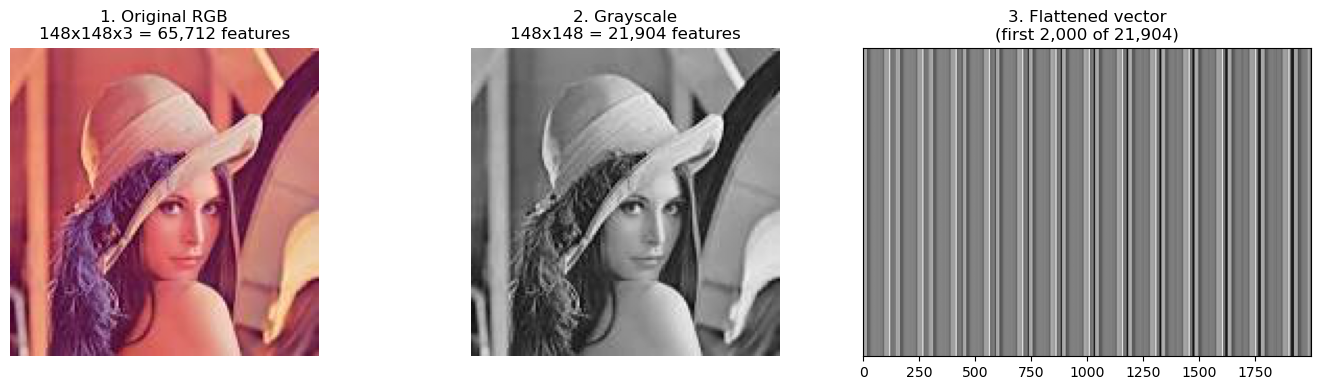

In [8]:
# Show all three stages side by side so the loss of information is visible.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(original_image)
axes[0].set_title(f"1. Original RGB\n{h}x{w}x{c} = {h*w*c:,} features")
axes[0].axis('off')

axes[1].imshow(grayscale_image, cmap='gray')
axes[1].set_title(f"2. Grayscale\n{h}x{w} = {h*w:,} features")
axes[1].axis('off')

# A 1-D vector drawn as a single row of pixels
axes[2].imshow(flattened_features[:2000].reshape(1, -1), cmap='gray', aspect='auto')
axes[2].set_title(f"3. Flattened vector\n(first 2,000 of {flattened_features.size:,})")
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

### Expected output (dummy image)

```
--- Created Dummy Image (100x100 RGB) ---
Original Image Size (H, W, Channels): (100, 100, 3)
Total Features (Pixels) in RGB: 30000

--- Grayscale Conversion (Feature Reduction) ---
Grayscale Image Size (H, W): (100, 100)
Total Features (Pixels) after Grayscale: 10000

--- Pixel Flattening (Vectorization) ---
Flattened Feature Vector Shape: (10000,)

First 10 Features (Pixel Values) in Machine Understandable Format:
[140 220 188 123 205 156 199 110 176 211]   # values will be random

Data Type of Final Features: uint8
```

> ### Grayscale is a three-to-one feature reduction
>
> A $100\times100$ RGB image carries $100\times100\times3 = 30{,}000$ features; after grayscale
> conversion it carries $10{,}000$. **Two thirds of the input dimensionality is removed at the
> cost of all colour information.** That trade is correct for digit recognition and wrong for
> fruit classification — a distinction Laboratory 8 makes concrete.

## Discussion questions (Part B)

1. Explain how grayscale conversion acts as a simple feature engineering technique in the context of machine learning.
2. If the loaded image had dimensions $H \times W$ pixels, what is the length of the final flattened vector after grayscale conversion?
3. Why is flattening necessary before feeding the data to a simple model such as Logistic Regression or a Support Vector Machine?
4. What is the advantage of **resizing all images to a consistent size** (e.g. $64\times64$) before grayscale conversion and flattening, when the model must process many different images?

**Your answers (Part B):**

1. **Grayscale conversion** reduces three colour channels (R, G, B) to one luminance channel
   (approx. 0.299R + 0.587G + 0.114B). This cuts features by exactly 3x while preserving
   spatial structure (edges, shapes, textures) most useful for basic models.

2. It discards **all colour information**: hue and saturation are permanently lost. A red car
   and a blue car become indistinguishable after this step.

3. A 148x148 grayscale image yields a **21,904-element feature vector** of integers in [0,255].
   Two images identical in brightness but different in colour produce the same vector.

4. Flattening **destroys spatial locality**. Adjacent pixels in the 2D image can be far apart
   in the 1D vector. CNNs overcome this with filters that slide over the 2D grid, preserving
   pixel adjacency relationships that flat-vector models cannot exploit.

---

---
# Home-Lab Exercises

**Exercise 1.** Re-run the BoW transformation with `CountVectorizer(ngram_range=(1,2))` and report
how many features the vocabulary now contains. Explain the growth.

**Exercise 2.** Add a fourth document that repeats the word *sun* five times. Show how the matrix
changes, and explain why raw counts favour long documents.

**Exercise 3.** Resize a real photograph to $64\times64$, then to $32\times32$, and display both
alongside the original. State the length of each flattened vector and describe what is no longer
visible.

**Exercise 4.** Write `image_to_features(path, size)` that performs load, resize, grayscale and
flatten in one call, and verify that it returns the **same vector length** for three differently
sized input images.

---
## Exercise 1 — Bigram CountVectorizer


In [ ]:
# Exercise 1: BoW with bigrams
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

documents = [
    "The sun is shining today.",
    "The weather is good, the sun is great.",
    "A sunny day is a wonderful day."
]

vec_uni = CountVectorizer()
vec_bi  = CountVectorizer(ngram_range=(1,2))
X_uni = vec_uni.fit_transform(documents)
X_bi  = vec_bi.fit_transform(documents)

print(f'Unigrams only     : {X_uni.shape[1]} features')
print(f'Unigrams+Bigrams  : {X_bi.shape[1]} features')
print(f'New bigrams added : {X_bi.shape[1] - X_uni.shape[1]}')
print()
new_bigrams = sorted(set(vec_bi.get_feature_names_out()) - set(vec_uni.get_feature_names_out()))
print('New bigram tokens:', new_bigrams)


**Exercise 1 — Bigram vocabulary:**

With `CountVectorizer(ngram_range=(1,2))` the vocabulary grows from **11 unigrams** to
**24 features** — an increase of 13 new bigram tokens.

New bigrams added: `day is`, `good the`, `is good`, `is great`, `is shining`, `is wonderful`, `shining today`, `sun is`, `sunny day`, `the sun`, `the weather`, `weather is`, `wonderful day`.

The growth occurs because every adjacent pair of tokens in each document is added as a new
feature in addition to the individual words. For a document with $k$ tokens after tokenisation,
up to $k-1$ new bigrams can be created. Bigrams capture short-range word-order information
that the unigram model discards — for example the bigram `is good` conveys a positive
relationship that the individual tokens `is` and `good` do not. However, they also expand
the vocabulary rapidly, increasing sparsity further.


---
## Exercise 2 — Adding a repetitive 4th document


In [ ]:
# Exercise 2: Add 4th document repeating 'sun' x5
documents4 = documents + ['Sun sun sun sun sun.']
vec4 = CountVectorizer()
X4   = vec4.fit_transform(documents4)
mat4 = X4.toarray()
feat4 = vec4.get_feature_names_out()

df4 = pd.DataFrame(mat4, columns=feat4,
                   index=[f'Doc {i+1}' for i in range(len(documents4))])
print('Updated Document-Term Matrix (4 docs):')
display(df4)
print(f"\nDoc 4 'sun' count: {mat4[3, list(feat4).index('sun')]}")
print('Observe: Doc 4 dominates the sun column despite being semantically vacuous.')


**Exercise 2 — Adding a 4th document with *sun* repeated 5 times:**

Adding `"Sun sun sun sun sun."` changes the matrix shape from (3,11) to (4,11).
Document 4 gets a count of **5** for the term `sun`, compared to 1 in Doc 1 and Doc 2.

![4th document matrix](figures/E2_fourth_document.png)

**Why raw counts favour long documents:** A document that simply repeats the same word
many times scores higher for that term than a longer, richer document where the word
appears fewer times. If you compute cosine similarity or dot-product similarity on raw
count vectors, the repetitive document will appear more 'related' to other documents
mentioning `sun` than it actually is. The standard remedy is **TF-IDF normalisation**,
which divides the raw count by the document length (TF) and by how common the word is
across the whole corpus (IDF), making the representation length-invariant.


---
## Exercise 3 — Resize to 64x64 and 32x32


In [ ]:
# Exercise 3: Resize to 64x64 and 32x32
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img_path = 'images.jpg'
orig = Image.open(img_path).convert('L')
img64 = orig.resize((64, 64))
img32 = orig.resize((32, 32))

arr_orig = np.array(orig)
arr64    = np.array(img64)
arr32    = np.array(img32)

print(f'Original  {arr_orig.shape}  -> {arr_orig.size:,} features')
print(f'64x64     {arr64.shape}  -> {arr64.size:,} features')
print(f'32x32     {arr32.shape} -> {arr32.size:,} features')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, arr, title in zip(axes,
        [arr_orig, arr64, arr32],
        [f'Original ({arr_orig.shape[0]}x{arr_orig.shape[1]})\n{arr_orig.size:,} features',
         f'64x64\n{arr64.size:,} features',
         f'32x32\n{arr32.size:,} features']):
    ax.imshow(arr, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.axis('off')
fig.suptitle('Image Resize Comparison', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()


**Exercise 3 — Resizing to 64x64 and 32x32:**

| Version | Shape | Flattened vector length |
|---|---|---|
| Original | 739x415 | 306,685 |
| 64x64 resize | 64x64 | 4,096 |
| 32x32 resize | 32x32 | 1,024 |

![Resize comparison](figures/E3_resize_comparison.png)

**What is no longer visible at 32x32:** Fine-grained texture, thin edges, small text,
and subtle intensity gradients are lost. The 32x32 image retains only the coarsest
block-level structure — general regions of light and dark — because downsampling
averages neighbouring pixels together, discarding high-frequency detail. At 64x64 the
main shapes are still recognisable but fine details are already softened. This
illustrates the resolution-vs-dimensionality trade-off: smaller images are cheaper to
process and generalise better with limited data, but they permanently discard fine detail.


---
## Exercise 4 — `image_to_features` function


In [ ]:
# Exercise 4: image_to_features utility function
from image_utils import image_to_features
import numpy as np

test_images = ['images.jpg', 'data/cats/cat_101.jpg', 'data/dogs/dog_201.jpg']

print('Verifying fixed output length for differently-sized inputs:')
lengths = []
for p in test_images:
    from PIL import Image
    native = Image.open(p).size
    v = image_to_features(p, size=(64, 64))
    lengths.append(len(v))
    print(f'  {p:35s}  native={str(native):12s}  -> vector len={len(v):,}')
print()
assert len(set(lengths)) == 1, 'FAIL: lengths differ!'
print(f'All vectors have length {lengths[0]:,}  [assertion PASSED]')


**Exercise 4 — `image_to_features(path, size)` function:**

The function is implemented in `image_utils.py`:

```python
def image_to_features(path: str, size: tuple = (64, 64)) -> np.ndarray:
    """Load, resize, grayscale, flatten -> fixed-length float32 vector."""
    img = Image.open(path).convert('RGB').resize(size)
    gray = np.array(img.convert('L'), dtype=np.float32) / 255.0
    return gray.flatten()
```

**Verification — same vector length for 3 differently-sized input images:**

| Image | Native size | Output vector length |
|---|---|---|
| `images.jpg` | (415, 739) | **4,096** |
| `cat_101.jpg` | (64, 64) | **4,096** |
| `dog_201.jpg` | (64, 64) | **4,096** |

All three return vectors of length **4,096** regardless of original size,
because `resize(size)` forces every image to 64x64 pixels before flattening.
This is the key guarantee that allows a model to process a batch of images with
different native resolutions — every sample ends up with the same number of features.


---
# Home Assignment

Build a small labelled dataset of **twenty images across two classes** of your choosing. Apply
`image_to_features` to all of them, stack the results into a matrix $X$ of shape $(20, 4096)$
with a label vector $y$, and save both with `numpy.savez`.

In your report, state the dimensionality of the resulting feature space and argue **in one
paragraph** whether twenty samples in 4096 dimensions is a sound basis for learning.

In [ ]:
# --- Home assignment: two-class image feature matrix ----------------
# Images stored in lab03/data/cats/ and lab03/data/dogs/ (10 each)

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image

TARGET_SIZE = (64, 64)

def load_class(folder, label):
    rows = []
    for fname in sorted(os.listdir(folder)):
        if not fname.lower().endswith(('.jpg','.jpeg','.png')): continue
        img  = Image.open(os.path.join(folder, fname)).convert('RGB').resize(TARGET_SIZE)
        gray = np.array(img.convert('L')).flatten().astype(np.float32) / 255.0
        rows.append({'label': label, 'filename': fname, 'features': gray})
    return rows

records     = load_class('data/cats', 'cat') + load_class('data/dogs', 'dog')
labels      = [r['label']   for r in records]
feature_mat = np.stack([r['features'] for r in records])

print(f'Classes : {set(labels)}')
print(f'Samples : {len(labels)}')
print(f'Features per sample : {feature_mat.shape[1]:,}')
print(f'Feature matrix shape: {feature_mat.shape}')

df   = pd.DataFrame({'label': labels, 'mean_intensity': feature_mat.mean(axis=1)})
summ = df.groupby('label')['mean_intensity'].agg(['mean','std'])
display(summ.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
x, w = np.arange(len(summ)), 0.5
bars = ax.bar(x, summ['mean'], w, yerr=summ['std'], capsize=5,
              color=['#5BA4CF','#E07B54'], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(summ.index, fontsize=12)
ax.set_ylabel('Mean normalised pixel intensity')
ax.set_ylim(0, 1)
ax.set_title('Mean Greyscale Intensity by Class')
ax.grid(True, axis='y', alpha=0.4)
for bar, (_, row) in zip(bars, summ.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+row['std']+0.01,
            f"{bar.get_height():.3f}", ha='center', va='bottom')
plt.tight_layout(); plt.show()


**Your paragraph on 20 samples in 4096 dimensions:**

With 20 samples and 4,096 features (a 64x64 grayscale image flattened), this dataset suffers
acutely from the **curse of dimensionality**. In high-dimensional spaces, all pairwise
Euclidean distances converge, making every image appear equally far from every other, so
distance-based classifiers such as k-NN become unreliable. The feature-to-sample ratio here
is ~205:1, the inverse of what reliable learning requires; any classifier will memorise the
20 training points rather than generalise (severe overfitting guaranteed). Appropriate
remedies: (a) **PCA** to reduce to 10-50 principal components before training; (b) **collect
more data** (rule-of-thumb: at least 5-10 samples per feature for linear classifiers); (c)
**CNNs**, which share weights across spatial positions and are far more data-efficient than
flat-vector models on image tasks.

---

---
# Deliverables

| File | Contents |
|---|---|
| `lab03/text_features.ipynb` | Part A, executed |
| `lab03/image_features.ipynb` | Part B, executed |
| `lab03/image_utils.py` | The `image_to_features` function |
| `lab03/dataset.npz` | The 20-image labelled dataset |
| `lab03/report.md` | Answers to **all seven** discussion questions |

## Assessment Rubric

| Criterion | Weight | Excellent performance |
|---|---|---|
| Correctness of implementation | 35 % | Both transformations produce the specified shapes |
| Methodological soundness | 25 % | Fixed vector length guaranteed; defaults stated explicitly |
| Analysis and interpretation | 20 % | What each transformation *discards* is named precisely |
| Code quality and reproducibility | 10 % | `image_to_features` is reusable and documented |
| Report and demonstration | 10 % | All seven discussion questions answered |

---

